In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

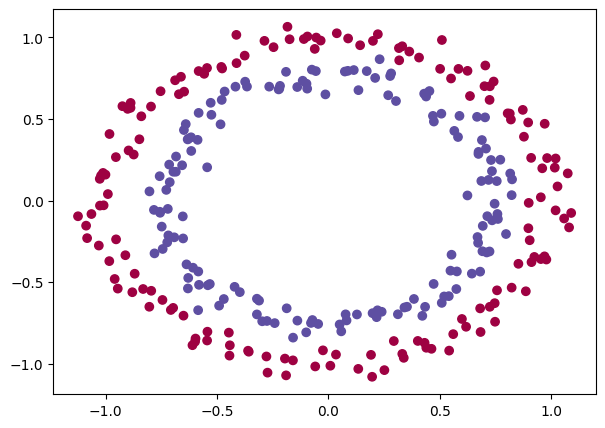

X shape: (2, 300)
Y shape: (1, 300)


In [52]:
# Generate dataset
X, Y = make_circles(
    n_samples=300,
    noise=0.05,
    factor=0.75,
    random_state=1
)

# Convert to Coursera format
X = X.T      # shape (2, m)
Y = Y.reshape(1, -1)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(
    X[0, :],
    X[1, :],
    c=Y.flatten(),
    cmap=plt.cm.Spectral
)
plt.show()

print("X shape:", X.shape)
print("Y shape:", Y.shape)

In [53]:
layers_dims = [X.shape[0], 10, 5, 1]

In [54]:
#initialize parameters with zeros
def initialize_parameters_zeros(layers_dims):
    np.random.seed(1)
    parameters = {}
    L = len(layers_dims)
    for l in range(1,L):
        parameters['W'+str(l)] = np.zeros((layers_dims[l], layers_dims[l-1]))
        parameters['b'+str(l)] = np.zeros((layers_dims[l], 1))
    return parameters

In [55]:
#initialize parameters with random values
def initialize_parameters_random(layers_dims):
    np.random.seed(1)
    parameters = {}
    L = len(layers_dims)
    for l in range(1,L):
        parameters['W'+str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1]) * 1.0
        parameters["b" + str(l)] = np.zeros(
            (layers_dims[l], 1)
        )
    return parameters

In [56]:
#initialize parameters with He initialization
def initialize_parameters_he(layers_dims):
    np.random.seed(1)
    parameters = {}
    L = len(layers_dims)
    for l in range(1,L):
        parameters['W'+str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1]) * np.sqrt(2/layers_dims[l-1])
        parameters["b" + str(l)] = np.zeros(
            (layers_dims[l], 1)
        )
    return parameters


In [57]:
#Activation functions
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

In [58]:
#Forward propagation
def forward_propagation(X, parameters):

    W1 = parameters["W1"]
    b1 = parameters["b1"]

    W2 = parameters["W2"]
    b2 = parameters["b2"]

    W3 = parameters["W3"]
    b3 = parameters["b3"]

    # Layer 1
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    # Layer 2
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)

    # Output layer
    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)

    cache = (
        Z1, A1, W1, b1,
        Z2, A2, W2, b2,
        Z3, A3, W3, b3
    )

    return A3, cache

In [59]:
#Compute loss
def compute_loss(A3, Y):

    m = Y.shape[1]

    loss = -(1/m) * np.sum(
        Y * np.log(A3)
        +
        (1-Y) * np.log(1-A3)
    )

    return np.squeeze(loss)

In [60]:
#Backward propagation
def backward_propagation(X, Y, cache):

    m = X.shape[1]

    (
        Z1, A1, W1, b1,
        Z2, A2, W2, b2,
        Z3, A3, W3, b3
    ) = cache

    dZ3 = A3 - Y

    dW3 = (1/m) * np.dot(dZ3, A2.T)
    db3 = (1/m) * np.sum(
        dZ3,
        axis=1,
        keepdims=True
    )

    dA2 = np.dot(W3.T, dZ3)

    dZ2 = dA2 * (A2 > 0)

    dW2 = (1/m) * np.dot(dZ2, A1.T)

    db2 = (1/m) * np.sum(
        dZ2,
        axis=1,
        keepdims=True
    )

    dA1 = np.dot(W2.T, dZ2)

    dZ1 = dA1 * (A1 > 0)

    dW1 = (1/m) * np.dot(dZ1, X.T)

    db1 = (1/m) * np.sum(
        dZ1,
        axis=1,
        keepdims=True
    )

    gradients = {

        "dW1": dW1,
        "db1": db1,

        "dW2": dW2,
        "db2": db2,

        "dW3": dW3,
        "db3": db3
    }

    return gradients

In [61]:
#Update parameters
def update_parameters(parameters,
                      grads,
                      learning_rate):

    L = len(parameters) // 2

    for l in range(1, L + 1):

        parameters["W" + str(l)] -= (
            learning_rate
            * grads["dW" + str(l)]
        )

        parameters["b" + str(l)] -= (
            learning_rate
            * grads["db" + str(l)]
        )

    return parameters

In [62]:
def model(X, Y, learning_rate = 0.01, num_iterations = 15000, print_cost = True, initialization = "he"):
        
    grads = {}
    costs = [] # to keep track of the loss
    m = X.shape[1] # number of examples
    layers_dims = [X.shape[0], 10, 5, 1]
    
    # Initialize parameters dictionary.
    if initialization == "zeros":
        parameters = initialize_parameters_zeros(layers_dims)
    elif initialization == "random":
        parameters = initialize_parameters_random(layers_dims)
    elif initialization == "he":
        parameters = initialize_parameters_he(layers_dims)

    # Loop (gradient descent)

    for i in range(num_iterations):

        # Forward propagation: LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID.
        a3, cache = forward_propagation(X, parameters)
        
        # Loss
        cost = compute_loss(a3, Y)

        # Backward propagation.
        grads = backward_propagation(X, Y, cache)
        
        # Update parameters.
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # Print the loss every 1000 iterations
        if print_cost and i % 1000 == 0:
            print("Cost after iteration {}: {}".format(i, cost))
            costs.append(cost)
            
    # plot the loss
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()
    
    return parameters

In [63]:
def predict(X, parameters):

    A3, _ = forward_propagation(
        X,
        parameters
    )

    predictions = (A3 > 0.5)

    return predictions

In [64]:
def plot_decision_boundary(model, X, Y):

    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1

    h = 0.01

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model(grid)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.5)

    plt.scatter(
        X[0, :],
        X[1, :],
        c=Y.flatten(),
        cmap=plt.cm.Spectral,
        edgecolors="k"
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X.T,
    Y.flatten(),
    test_size=0.2,
    random_state=42
)

X_train = X_train.T
X_test = X_test.T

Y_train = Y_train.reshape(1, -1)
Y_test = Y_test.reshape(1, -1)

Cost after iteration 0: 0.6931471805599453
Cost after iteration 1000: 0.6931126904842925
Cost after iteration 2000: 0.6931124594934753
Cost after iteration 3000: 0.6931124579462675
Cost after iteration 4000: 0.6931124579359043
Cost after iteration 5000: 0.6931124579358346
Cost after iteration 6000: 0.6931124579358343
Cost after iteration 7000: 0.6931124579358343
Cost after iteration 8000: 0.6931124579358343
Cost after iteration 9000: 0.6931124579358343
Cost after iteration 10000: 0.6931124579358342
Cost after iteration 11000: 0.6931124579358344
Cost after iteration 12000: 0.6931124579358342
Cost after iteration 13000: 0.6931124579358344
Cost after iteration 14000: 0.6931124579358344


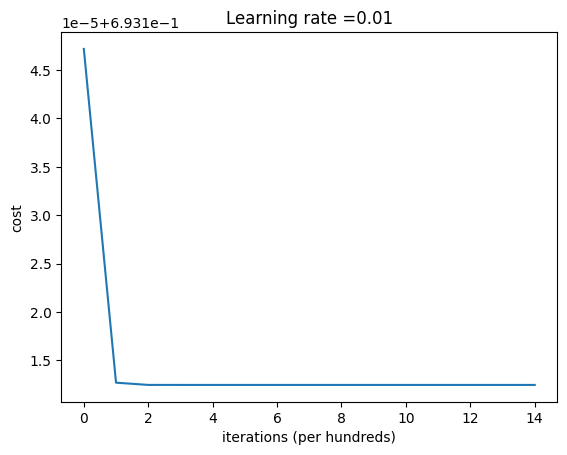

Train Accuracy: 50.416666666666664
Test Accuracy: 48.333333333333336


In [66]:
parameters = model(
    X_train,
    Y_train,
    initialization="zeros"
)

train_pred = predict(X_train, parameters)
test_pred = predict(X_test, parameters)

print(
    "Train Accuracy:",
    np.mean(train_pred == Y_train) * 100
)

print(
    "Test Accuracy:",
    np.mean(test_pred == Y_test) * 100
)

In [67]:
print("W1 norm =", np.linalg.norm(parameters["W1"]))
print("W2 norm =", np.linalg.norm(parameters["W2"]))
print("W3 norm =", np.linalg.norm(parameters["W3"]))

W1 norm = 0.0
W2 norm = 0.0
W3 norm = 0.0


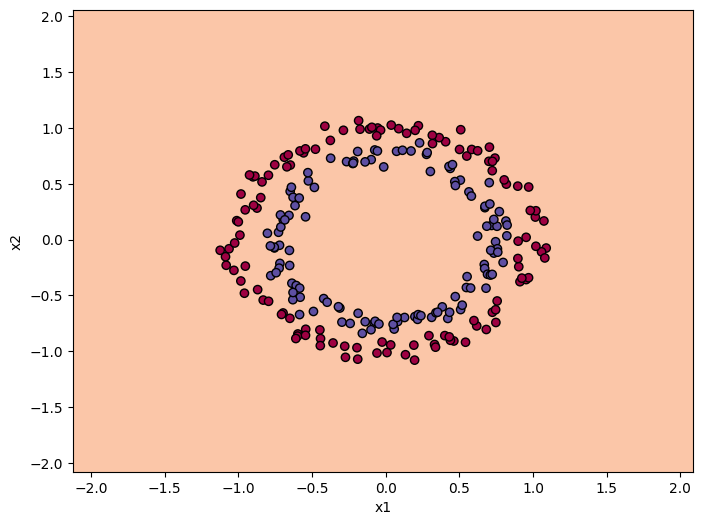

Text(0.5, 1.0, 'Decision Boundary (Train Set)')

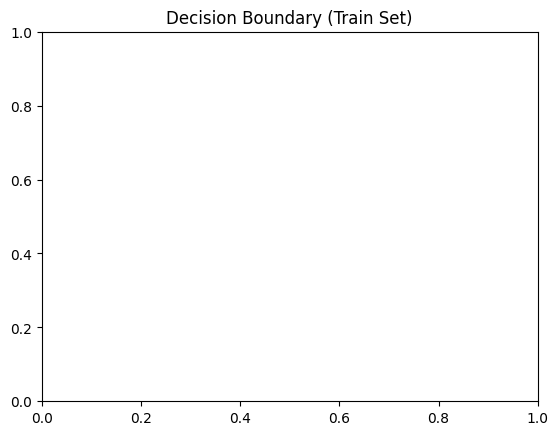

In [68]:
plot_decision_boundary(
    lambda x: predict(x.T, parameters).reshape(-1),
    X_train,
    Y_train
)

plt.title("Decision Boundary (Train Set)")

Cost after iteration 0: 0.7902677027710454
Cost after iteration 1000: 0.620126236925939
Cost after iteration 2000: 0.49118063971015263
Cost after iteration 3000: 0.33604022347576895
Cost after iteration 4000: 0.21389711962522082
Cost after iteration 5000: 0.14150348448905076
Cost after iteration 6000: 0.09922233306540558
Cost after iteration 7000: 0.07549330412247424
Cost after iteration 8000: 0.0609317732421991
Cost after iteration 9000: 0.05146894487240344
Cost after iteration 10000: 0.04477595317685591
Cost after iteration 11000: 0.039724291601460626
Cost after iteration 12000: 0.035798947806438754
Cost after iteration 13000: 0.03264205941576663
Cost after iteration 14000: 0.030022032366211034


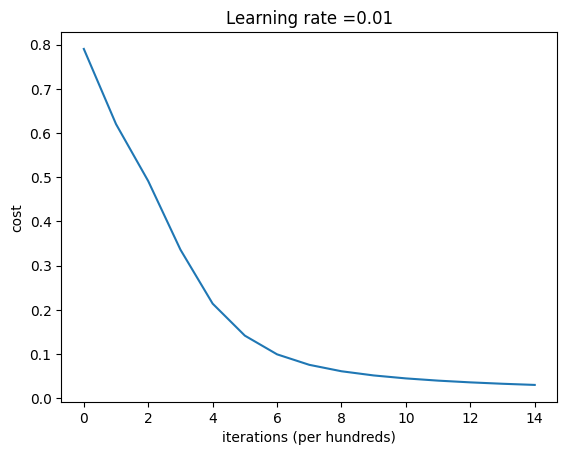

Train Accuracy: 100.0
Test Accuracy: 100.0


In [69]:
parameters = model(
    X_train,
    Y_train,
    initialization="random"
)

train_pred = predict(X_train, parameters)
test_pred = predict(X_test, parameters)

print(
    "Train Accuracy:",
    np.mean(train_pred == Y_train) * 100
)

print(
    "Test Accuracy:",
    np.mean(test_pred == Y_test) * 100
)

In [70]:
print("W1 norm =", np.linalg.norm(parameters["W1"]))
print("W2 norm =", np.linalg.norm(parameters["W2"]))
print("W3 norm =", np.linalg.norm(parameters["W3"]))

W1 norm = 6.70165720694008
W2 norm = 8.196579808536917
W3 norm = 5.708859923337977


In [71]:
A3, _ = forward_propagation(X_train, parameters)

print(np.min(A3))
print(np.max(A3))
print(np.mean(A3))

1.3518878995494538e-07
0.9999987604466174
0.49545429655688766


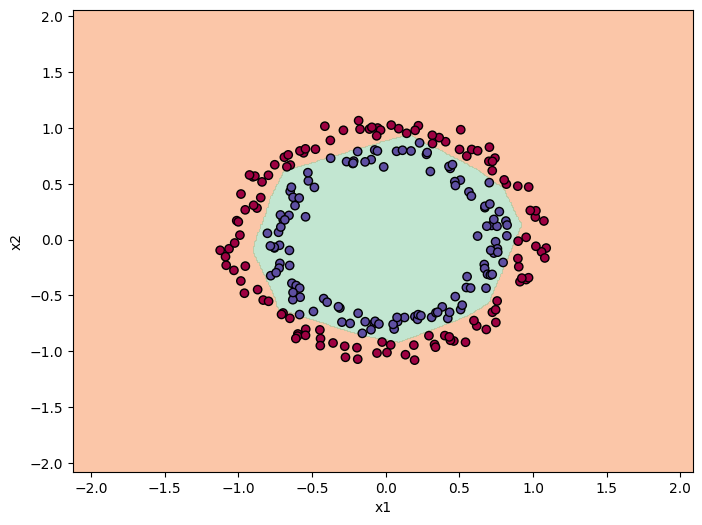

Text(0.5, 1.0, 'Decision Boundary (Train Set)')

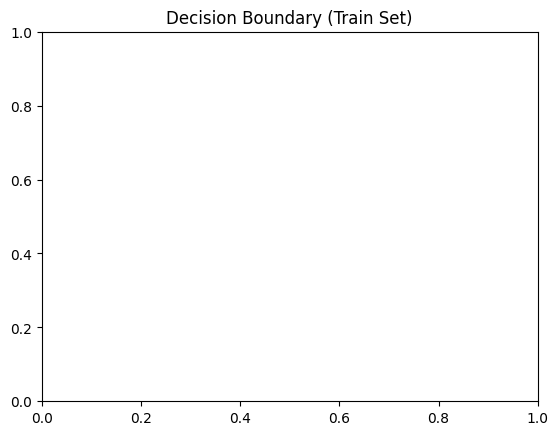

In [72]:
plot_decision_boundary(
    lambda x: predict(x.T, parameters).reshape(-1),
    X_train,
    Y_train
)

plt.title("Decision Boundary (Train Set)")

Cost after iteration 0: 0.7036153202242587
Cost after iteration 1000: 0.6793145521366484
Cost after iteration 2000: 0.6586344990005005
Cost after iteration 3000: 0.61009629903176
Cost after iteration 4000: 0.5154778521323273
Cost after iteration 5000: 0.3828234643637034
Cost after iteration 6000: 0.2641850217698744
Cost after iteration 7000: 0.1841744472648657
Cost after iteration 8000: 0.13509103493081487
Cost after iteration 9000: 0.10496665703918179
Cost after iteration 10000: 0.08471393771084997
Cost after iteration 11000: 0.07137551124407064
Cost after iteration 12000: 0.05955598278232603
Cost after iteration 13000: 0.05135886815250562
Cost after iteration 14000: 0.045574370987999484


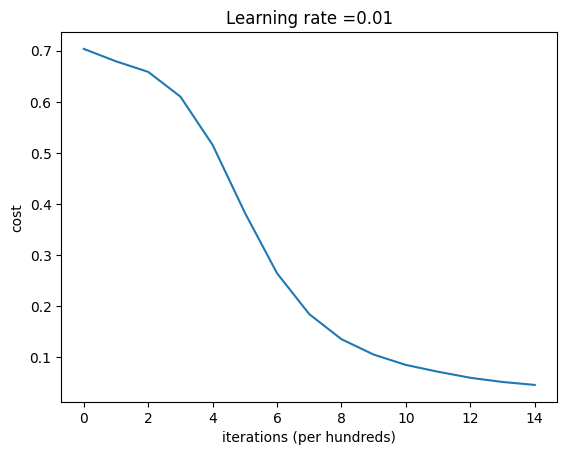

Train Accuracy: 100.0
Test Accuracy: 100.0


In [73]:
parameters = model(
    X_train,
    Y_train,
    initialization="he"
)

train_pred = predict(X_train, parameters)
test_pred = predict(X_test, parameters)

print(
    "Train Accuracy:",
    np.mean(train_pred == Y_train) * 100
)

print(
    "Test Accuracy:",
    np.mean(test_pred == Y_test) * 100
)

In [74]:
print("W1 norm =", np.linalg.norm(parameters["W1"]))
print("W2 norm =", np.linalg.norm(parameters["W2"]))
print("W3 norm =", np.linalg.norm(parameters["W3"]))

W1 norm = 6.485066126943742
W2 norm = 5.47844626092096
W3 norm = 5.687132948896643


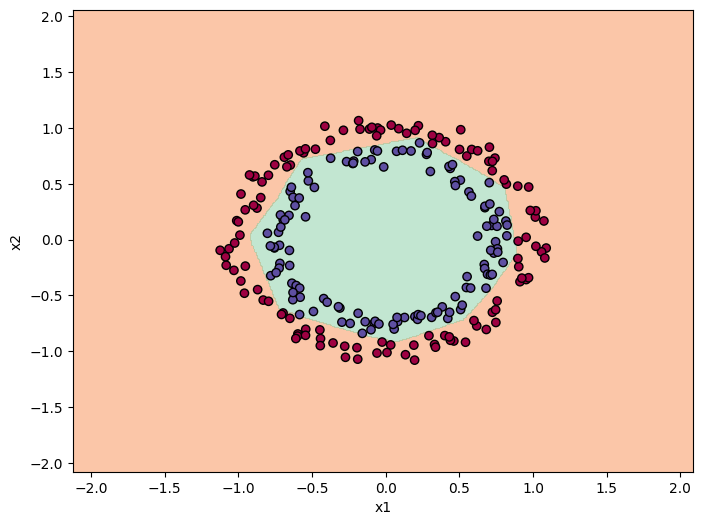

Text(0.5, 1.0, 'Decision Boundary (Train Set)')

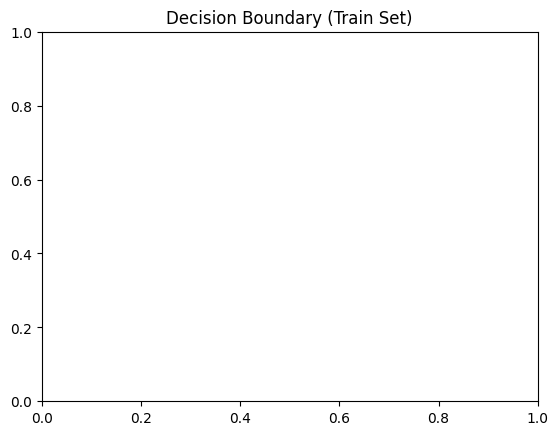

: 

In [ ]:
plot_decision_boundary(
    lambda x: predict(x.T, parameters).reshape(-1),
    X_train,
    Y_train
)

plt.title("Decision Boundary (Train Set)")